### Initialize paths

In [1]:
from pathlib import Path

# Subject ID
subid = "0001"

# Base directories
udel_dir = Path("/home/oana/UDel/UDELData")
udel_subj = udel_dir/f"U01_UDEL_{subid}_01_v3"
udel_anatomy = udel_subj/f"U01_UDEL_{subid}_01_SLANT"
fs_dir = udel_dir / "fsruns" / subid
mre_dir = Path("/home/oana/MRE_analysis") / subid


# MRE volumes
mre_files = {
    "stiffness": mre_dir / "MRE_stiffness_in_T1_space.nii.gz",
    "real": mre_dir / "MRE_real_in_T1_space.nii.gz",
    "imag": mre_dir / "MRE_imag_in_T1_space.nii.gz",
}

# T1W and T2w paths for later myelin calculation
t1w_path = udel_anatomy/f"U01_UDEL_{subid}_01_MPRAGEPre_norm_deface.nii.gz"
t2w_path = udel_anatomy/f"U01_UDEL_{subid}_01_3DT2_norm.nii.gz"

# Brain mask
brainmask_path = udel_anatomy/f"U01_UDEL_{subid}_01_MPRAGEPre_norm_slant_brainmask.nii.gz"

# Parcellation volume 
#regions_path=  udel_anatomy/f"U01_UDEL_{subid}_01_MPRAGEPre_norm_slant_macruise.nii.gz"
#regions_path= fs_dir/"mri/aparc.a2009s+aseg.mgz"



### Surface sampling

In [11]:
import numpy as np
import nibabel as nib
from cortech import Cortex
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

cortex = Cortex.from_freesurfer_subject_dir(fs_dir, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
#for hemi in [cortex.lh, cortex.rh]:
#    hemi.white.smooth_taubin(n_iter=5, inplace=True)
#    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}


#mask_img = nib.load(str(brainmask_dir))
#mask_data = mask_img.get_fdata()
#mask_affine = mask_img.affine

#surface_brainmask = {hemi: mid_layers[hemi].interpolate_to_nodes(mask_data, mask_affine) for hemi in ["lh","rh"]}

#surface_brainmask = {hemi: surface_brainmask[hemi] > 0.5 for hemi in ["lh","rh"]}

# interpolate all MRE data
surface_mre = {}

for name, vol_path in mre_files.items():
    img = nib.load(str(vol_path))
    data = img.get_fdata()
    affine = img.affine

    surface_mre[name] = {hemi: mid_layers[hemi].interpolate_to_nodes(data, affine) for hemi in ["lh", "rh"]}


# Myelin map
t1_img = nib.load(str(t1w_path))
t2_img = nib.load(str(t2w_path))
#mask_img = nib.load(str(brainmask_path))

t1_data = t1_img.get_fdata()
t2_data = t2_img.get_fdata()
#mask_data = mask_img.get_fdata().astype(bool)

t1_affine = t1_img.affine


#t1_masked = np.where(mask_data, t1_data, np.nan)
#t2_masked = np.where(mask_data, t2_data, np.nan)

#compute ratio only there both images arep positive
valid = (t1_data > 0) & (t2_data > 0)
myelin_data = np.where(valid, t1_data/(t2_data + 1e-3), 0)

# Interpolate myelin map to surface
surface_myelin = {hemi: mid_layers[hemi].interpolate_to_nodes(myelin_data, t1_affine) for hemi in ["lh", "rh"]}


# Regions 
#region_img = nib.load(str(regions_path))
#region_data = region_img.get_fdata().astype(int)
#region_affine = region_data.affine
#surface_regions = {hemi: mid_layers[hemi].interpolate_to_nodes(region_data, region_affine, method ="nearest").astype(int) for hemi in ["lh", "rh"]}

#Load parcellation
aparc = {
    "lh": nib.freesurfer.io.read_annot(fs_dir / "label" / "lh.aparc.a2009s.annot"),
    "rh": nib.freesurfer.io.read_annot(fs_dir / "label" / "rh.aparc.a2009s.annot"),
}


#Add geometry parameters

from nibabel.freesurfer import read_morph_data

curvature = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.curv"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.curv"),
}
#lh.inflated.K
#lh.inflated.H

thickness = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.thickness"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.thickness"),
}

sulcal_depth = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.sulc"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.sulc"),
}


In [119]:
myelinimage=nib.Nifti1Image(myelin_data,t1_affine)
nib.save(myelinimage,mre_dir/'myelinimg')

In [139]:
for hemi in ["lh","rh"]:
    arr=surface_myelin[hemi]
    print(hemi, np.min(arr), np.max(arr), np.mean(arr))

lh -1668.074025936861 865.3409288429635 0.5246696196650767
rh -87.10111513222375 367.2727308349703 0.5139658303678146


In [143]:
labels, ctab, names = nib.freesurfer.io.read_annot(fs_dir/'label/lh.aparc.a2009s.annot')
for i, name in enumerate(names):
    print(i, name.decode('utf-8'))

0 Unknown
1 G_and_S_frontomargin
2 G_and_S_occipital_inf
3 G_and_S_paracentral
4 G_and_S_subcentral
5 G_and_S_transv_frontopol
6 G_and_S_cingul-Ant
7 G_and_S_cingul-Mid-Ant
8 G_and_S_cingul-Mid-Post
9 G_cingul-Post-dorsal
10 G_cingul-Post-ventral
11 G_cuneus
12 G_front_inf-Opercular
13 G_front_inf-Orbital
14 G_front_inf-Triangul
15 G_front_middle
16 G_front_sup
17 G_Ins_lg_and_S_cent_ins
18 G_insular_short
19 G_occipital_middle
20 G_occipital_sup
21 G_oc-temp_lat-fusifor
22 G_oc-temp_med-Lingual
23 G_oc-temp_med-Parahip
24 G_orbital
25 G_pariet_inf-Angular
26 G_pariet_inf-Supramar
27 G_parietal_sup
28 G_postcentral
29 G_precentral
30 G_precuneus
31 G_rectus
32 G_subcallosal
33 G_temp_sup-G_T_transv
34 G_temp_sup-Lateral
35 G_temp_sup-Plan_polar
36 G_temp_sup-Plan_tempo
37 G_temporal_inf
38 G_temporal_middle
39 Lat_Fis-ant-Horizont
40 Lat_Fis-ant-Vertical
41 Lat_Fis-post
42 Medial_wall
43 Pole_occipital
44 Pole_temporal
45 S_calcarine
46 S_central
47 S_cingul-Marginalis
48 S_circular_in

### Descriptive statistics and visualization 

In [3]:
import pandas as pd

stiff_min=99 #Pa (=0.099 kPa)
rows=[]
for hemi in ["lh","rh"]:
    labels, ctab, names =aparc[hemi]
    #Extract hemi specific arrays
    curv = curvature[hemi]
    thick= thickness[hemi]
    stiff = surface_mre["stiffness"][hemi]
    real = surface_mre["real"][hemi] #shear real (storage modulus)
    imag = surface_mre["imag"][hemi]  #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi]
    myelin = surface_myelin[hemi]



    for lab_id, lab_name in enumerate(names):
        if lab_name ==b'unknown':
            continue

        mask=labels==lab_id

        if mask.sum()<50:
            continue


        rows.append({
            #"hemi":hemi,
            "region":lab_name.decode(),
            #"n_vertices":mask.sum(),
            "curvature":np.mean(abs(curv[mask])),
            "thickness":np.mean(abs(thick[mask])),
            "sulcal_depth":np.mean(abs(sulc[mask])),
            "stiffness":np.mean(stiff[mask]),
            "real":np.mean(real[mask]),
            "imag":np.mean(imag[mask]),
            "myelin":np.mean(myelin[mask]),
            
        })

    #Create a DataFrame 
    df_regions = pd.DataFrame(rows)

print(df_regions.describe())
df_regions.head()

    


        curvature   thickness  sulcal_depth    stiffness         real  \
count  148.000000  148.000000    148.000000   148.000000   148.000000   
mean     0.134356    2.606400      4.450139  2803.231201  2363.166824   
std      0.029424    0.421451      1.479738   620.609937   647.409199   
min      0.061695    1.626127      1.284202  1400.915110  1160.523499   
25%      0.112165    2.324682      3.595816  2351.585615  1909.320344   
50%      0.132460    2.604105      4.628807  2809.916074  2310.316536   
75%      0.158926    2.871311      5.246720  3224.240669  2725.087608   
max      0.204204    4.035236     10.665398  4557.185580  4355.728461   

              imag      myelin  
count   148.000000  148.000000  
mean   1089.437315    0.503792  
std     321.269872    0.109226  
min     138.014273    0.389122  
25%     905.037120    0.458396  
50%    1138.854642    0.473650  
75%    1296.983289    0.521029  
max    2011.472534    1.228667  


,region,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin
0,G_and_S_frontomargin,0.156307,2.359566,4.454088,2672.305750,2169.024890,1160.841062,0.463473
1,G_and_S_occipital_inf,0.175128,2.522959,3.725310,2159.735064,1654.087184,1067.187716,0.571738
2,G_and_S_paracentral,0.148191,2.469780,5.166354,1826.179042,1756.004871,301.659483,0.624398
3,G_and_S_subcentral,0.139747,3.120707,5.276268,2821.616571,2258.336573,1313.325737,0.467477
4,G_and_S_transv_frontopol,0.200021,2.654696,6.551912,2737.017653,2274.626641,1162.380858,0.467136


            "region":lab_name.decode(),
            #"n_vertices":mask.sum(),
            "curvature":np.mean(np.abs(curv[mask])),
            "thickness":np.mean(np.abs(thick[mask])),
            "sulcal_depth":np.mean(np.abs(sulc[mask])),
            "stiffness":np.mean(np.abs(stiff[mask])),
            "real":np.mean(np.abs(real[mask])),
            "imag":np.mean(np.abs(imag[mask])),
            "myelin":np.mean(np.abs(myelin[mask])),

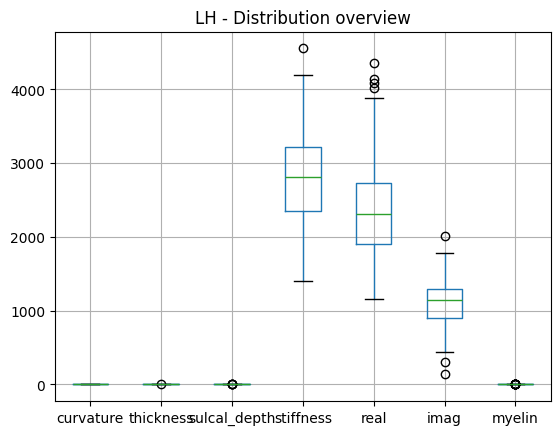

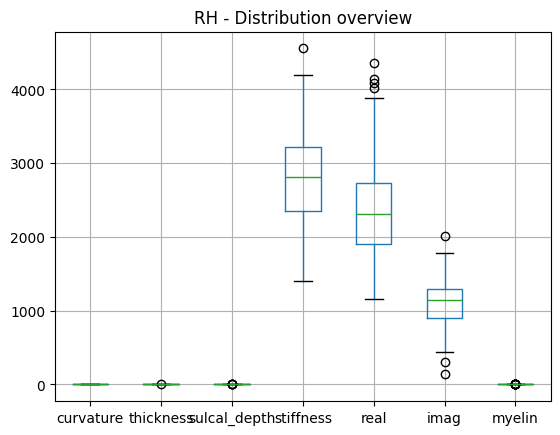

In [4]:
import matplotlib.pyplot as plt
for hemi in ["lh","rh"]:
    df_regions.boxplot()
    plt.title(f"{hemi.upper()} - Distribution overview")
    plt.show()


In [5]:
import statsmodels.api as sm
x=df_regions[["stiffness","real","imag"]]
x=sm.add_constant(x)
y=df_regions["curvature"]

model=sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     16.04
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           4.73e-09
Time:                        16:43:46   Log-Likelihood:                 333.68
No. Observations:                 148   AIC:                            -659.4
Df Residuals:                     144   BIC:                            -647.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2005      0.011     18.431      0.0

In [136]:
import statsmodels.api as sm
x=df_regions[["stiffness","real","imag"]]
x=sm.add_constant(x)
y=df_regions["sulcal_depth"]

model=sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     29.66
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           5.43e-15
Time:                        15:42:25   Log-Likelihood:                -384.27
No. Observations:                 148   AIC:                             776.5
Df Residuals:                     144   BIC:                             788.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.5794      1.392     -7.601      0.0

In [137]:
import statsmodels.api as sm
x=df_regions[["stiffness","real","imag"]]
x=sm.add_constant(x)
y=df_regions["thickness"]

model=sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     4.752
Date:                Mon, 16 Feb 2026   Prob (F-statistic):            0.00344
Time:                        15:42:39   Log-Likelihood:                -74.636
No. Observations:                 148   AIC:                             157.3
Df Residuals:                     144   BIC:                             169.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4229      0.172     14.105      0.0

In [ ]:
import pandas as pd

stiff_min=500 #Pa (=0.5 kPa)

for hemi in ["lh","rh"]:
    #Extract hemi specific arrays
    curv = curvature[hemi].astype(np.float64)
    thick= thickness[hemi].astype(np.float64)
    stiff = surface_mre["stiffness"][hemi].astype(np.float64)
    real = surface_mre["real"][hemi].astype(np.float64) #shear real (storage modulus)
    imag = surface_mre["imag"][hemi].astype(np.float64) #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi].astype(np.float64)
    myelin = surface_myelin[hemi].astype(np.float64)

    #Stiffness mask that eliminates values around zero
    stiff_mask=(np.isfinite(stiff) & (stiff >= stiff_min))

    #Apply the mask to the other 
    curv_m=curv[stiff_mask]
    thick_m=thick[stiff_mask]
    stiff_m = stiff[stiff_mask]
    real_m =real[stiff_mask]
    imag_m = imag[stiff_mask]
    sulc_m =sulc[stiff_mask]
    myelin_m=myelin[stiff_mask]

    #Check values
    print(f"Initial vertices {hemi.upper()}:",len(stiff), f"({len(myelin)== len(imag) & len(stiff)==len(curv)})")
    print(f"After filtering vertices {hemi.upper()}:",len(stiff_m), f"({len(myelin_m)== len(imag_m) & len(stiff_m)==len(curv_m)})")

    #Transform shear stiffness, storage modulus and loss modulus to kPa
    stiff_kpa = stiff_m/1000
    real_kpa = real_m/1000
    imag_kpa = imag_m/1000

    #Create a DataFrame 
    df = pd.DataFrame({
        "curvature":curv_m,
        "thickness":thick_m,
        "sulcal_depth":sulc_m,
        "stiffness":stiff_kpa,
        "real":real_kpa,
        "imag":imag_kpa,
        "myelin":myelin_m,
    })

df.describe()

    


Initial vertices LH: 158340 (True)
After filtering vertices LH: 150294 (True)
Initial vertices RH: 159948 (True)
After filtering vertices RH: 151872 (True)


,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin
count,151872.000000,151872.000000,151872.000000,151872.000000,151872.000000,151872.000000,151872.000000
mean,-0.018739,2.385301,0.333038,2.864159,2.425582,1.086296,0.510124
std,0.159578,0.905382,5.523244,0.813685,0.856645,0.452541,1.482137
min,-0.643204,0.000000,-14.329679,0.500082,0.112604,0.004948,-88.700641
25%,-0.133655,1.953984,-3.889414,2.359918,1.850910,0.790829,0.424882
50%,0.003438,2.472742,-0.045689,2.818702,2.345262,1.122139,0.472551
75%,0.109672,2.963491,4.300436,3.360372,2.934878,1.395654,0.540407
max,0.430637,5.000000,16.251078,6.289461,6.239851,2.699844,268.281930


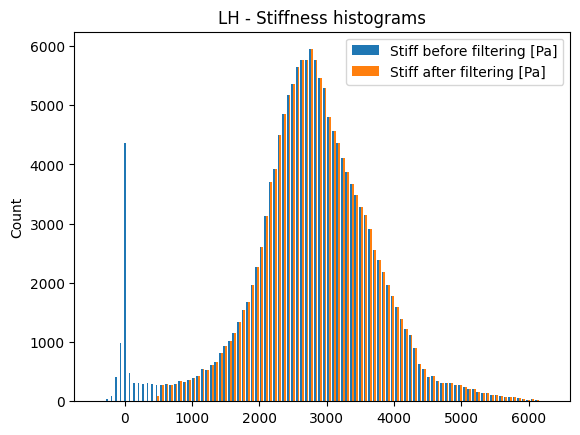

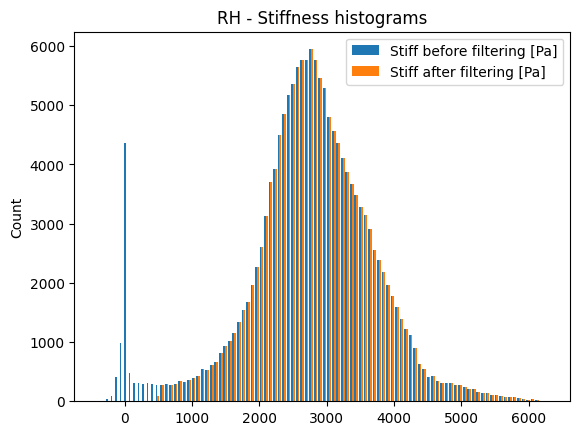

In [13]:

for hemi in ["lh","rh"]:
    plt.hist([stiff, stiff_m], bins=100, label=["Stiff before filtering [Pa]","Stiff after filtering [Pa]"])
    plt.ylabel("Count")
    plt.title(f"{hemi.upper()} - Stiffness histograms")
    plt.legend()
    plt.show()



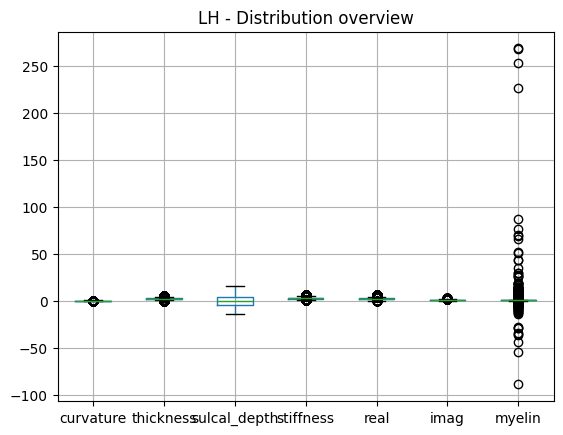

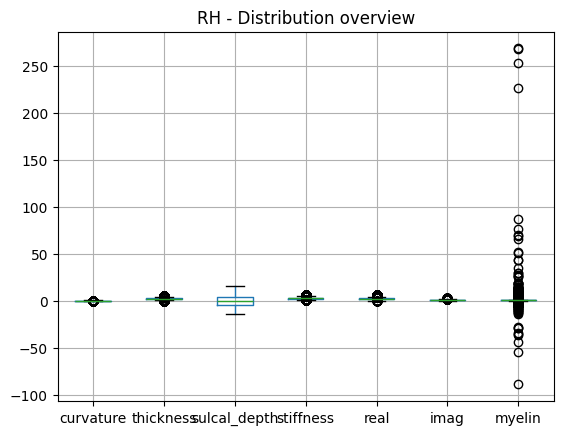

In [14]:
import matplotlib.pyplot as plt
for hemi in ["lh","rh"]:
    df.boxplot()
    plt.title(f"{hemi.upper()} - Distribution overview")
    plt.show()


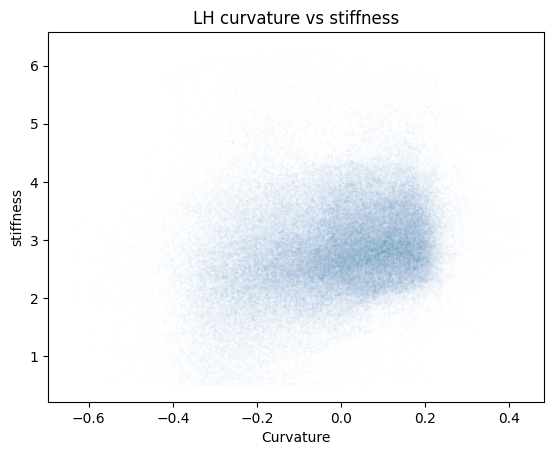

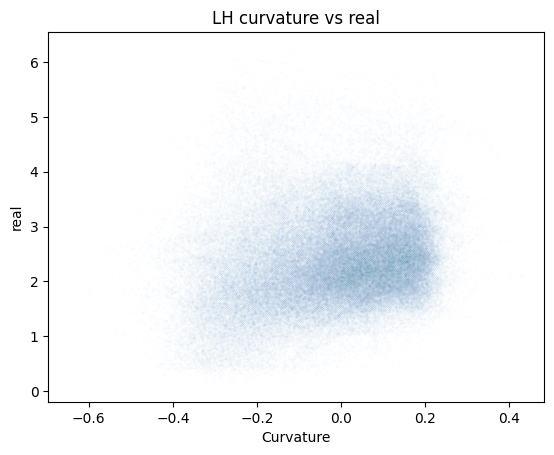

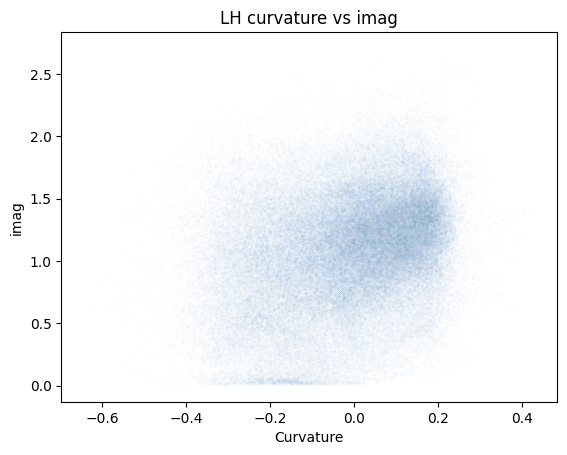

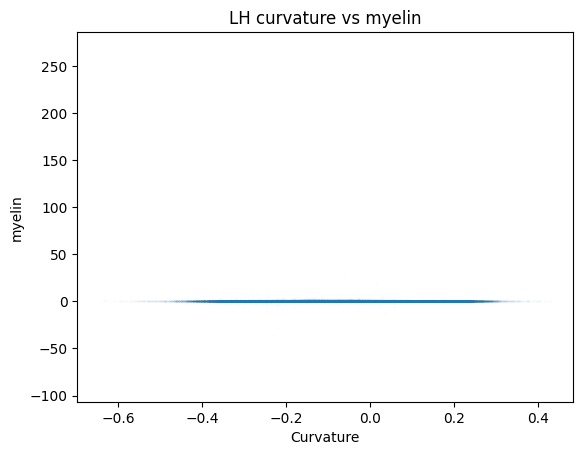

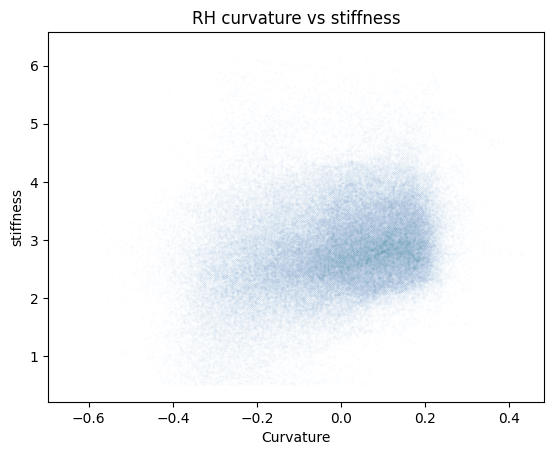

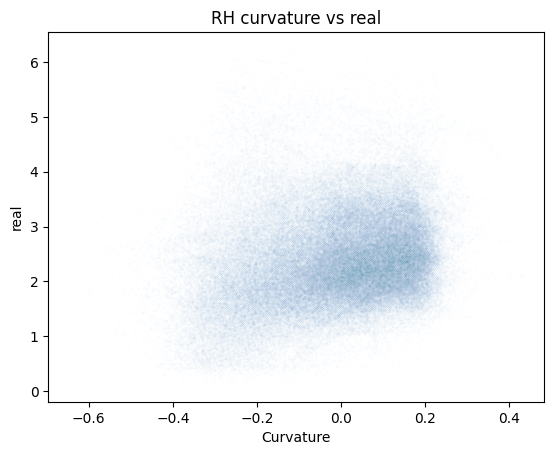

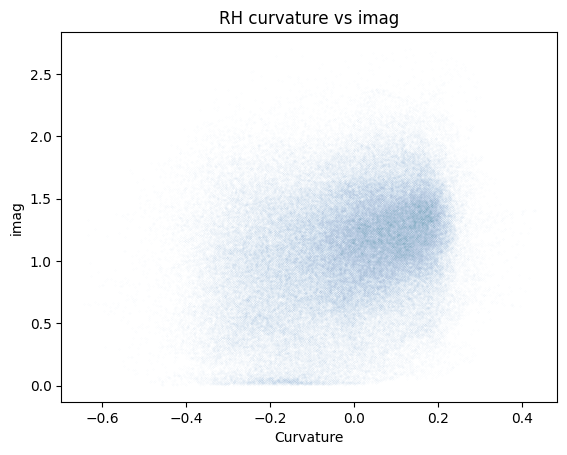

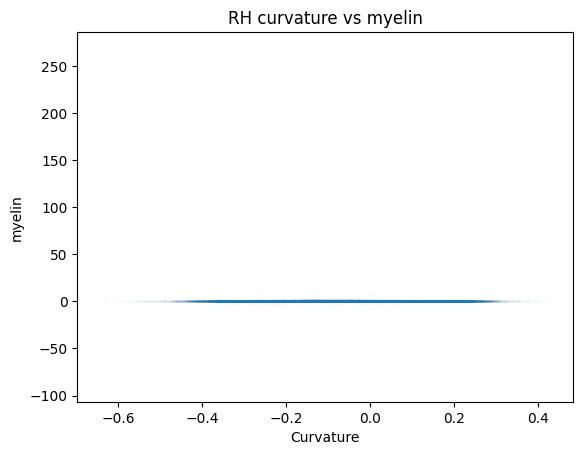

In [15]:
for hemi in ["lh","rh"]:
    for prop in ["stiffness","real","imag","myelin"]:
        plt.scatter(df["curvature"], df[prop], s=0.0001)
        plt.xlabel("Curvature")
        plt.ylabel(prop)
        plt.title (f"{hemi.upper()} curvature vs {prop}")
        plt.show()

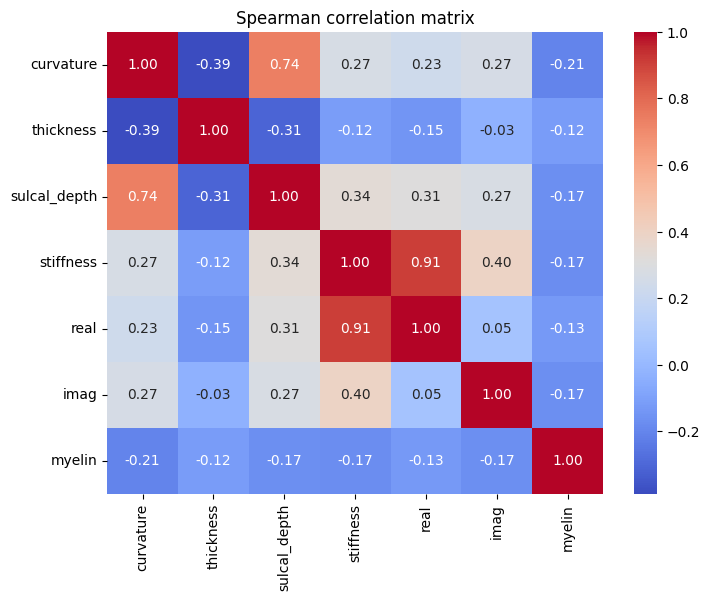

In [16]:
import seaborn as sns

corr_s =df.corr(method="spearman")
plt.figure(figsize=(8,6))
sns.heatmap(corr_s, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman correlation matrix")
plt.show()


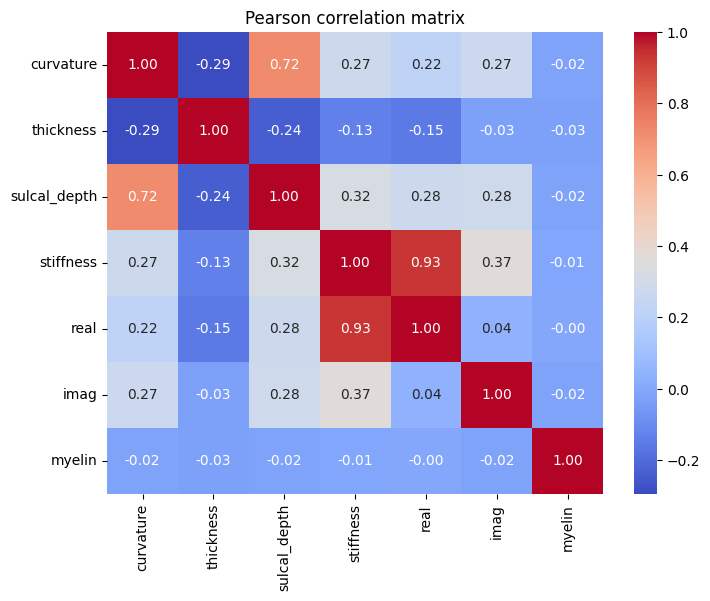

In [17]:
corr_p =df.corr(method="pearson")
plt.figure(figsize=(8,6))
sns.heatmap(corr_p, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson correlation matrix")
plt.show()

In [18]:
from scipy.stats import pearsonr, spearmanr

results = {}
# Correlations with curvature
for hemi in ["lh", "rh"]:
    results[hemi] = {}
    for prop in ["stiffness", "real", "imag","myelin"]:
        #Curvature
        r_p, p_p =pearsonr(df[prop], df["curvature"])
        r_s, p_s =spearmanr(df[prop], df["curvature"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs curvature \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")

        #Thickness

        r_p, p_p =pearsonr(df[prop], df["thickness"])
        r_s, p_s =spearmanr(df[prop], df["thickness"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs thicnkess \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")



        r_p, p_p =pearsonr(df[prop], df["sulcal_depth"])
        r_s, p_s =spearmanr(df[prop], df["sulcal_depth"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs sulcal depth \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")



LH stiffness vs curvature 
 Pearson r=0.274, p=0.00e+00 
 Spearman r=0.270, p=0.00e+00
LH stiffness vs thicnkess 
 Pearson r=-0.133, p=0.00e+00 
 Spearman r=-0.117, p=0.00e+00
LH stiffness vs sulcal depth 
 Pearson r=0.324, p=0.00e+00 
 Spearman r=0.336, p=0.00e+00
LH real vs curvature 
 Pearson r=0.221, p=0.00e+00 
 Spearman r=0.233, p=0.00e+00
LH real vs thicnkess 
 Pearson r=-0.153, p=0.00e+00 
 Spearman r=-0.145, p=0.00e+00
LH real vs sulcal depth 
 Pearson r=0.276, p=0.00e+00 
 Spearman r=0.307, p=0.00e+00
LH imag vs curvature 
 Pearson r=0.268, p=0.00e+00 
 Spearman r=0.267, p=0.00e+00
LH imag vs thicnkess 
 Pearson r=-0.030, p=3.61e-32 
 Spearman r=-0.030, p=2.28e-32
LH imag vs sulcal depth 
 Pearson r=0.284, p=0.00e+00 
 Spearman r=0.274, p=0.00e+00
LH myelin vs curvature 
 Pearson r=-0.020, p=1.38e-15 
 Spearman r=-0.206, p=0.00e+00
LH myelin vs thicnkess 
 Pearson r=-0.030, p=1.83e-32 
 Spearman r=-0.119, p=0.00e+00
LH myelin vs sulcal depth 
 Pearson r=-0.019, p=3.87e-13 
 S

In [19]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["curvature"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere: curvature ~ stiffness")
    print(model.summary())


LH hemisphere: curvature ~ stiffness
                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                 1.229e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:46:14   Log-Likelihood:                 69132.
No. Observations:              151872   AIC:                        -1.383e+05
Df Residuals:                  151870   BIC:                        -1.382e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

In [20]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["curvature"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: curvature ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere multiple regression: curvature ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     6000.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:46:39   Log-Likelihood:                 74363.
No. Observations:              151872   AIC:                        -1.487e+05
Df Residuals:                  151867   BIC:                        -1.487e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [21]:
for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["sulcal_depth"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: sulcal_depth ~ stiffness")
    print(model.summary())


LH hemisphere multiple regression: sulcal_depth ~ stiffness
                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                 1.785e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:46:50   Log-Likelihood:            -4.6660e+05
No. Observations:              151872   AIC:                         9.332e+05
Df Residuals:                  151870   BIC:                         9.332e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [22]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["sulcal_depth"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere: sulcal_depth ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere: sulcal_depth ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     8527.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:46:57   Log-Likelihood:            -4.5966e+05
No. Observations:              151872   AIC:                         9.193e+05
Df Residuals:                  151867   BIC:                         9.194e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [23]:
for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["thickness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: thickness~ stiffness")
    print(model.summary())


LH hemisphere multiple regression: thickness~ stiffness
                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2744.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:47:09   Log-Likelihood:            -1.9904e+05
No. Observations:              151872   AIC:                         3.981e+05
Df Residuals:                  151870   BIC:                         3.981e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [24]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["thickness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: thickness ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere multiple regression: thickness ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1662.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:47:20   Log-Likelihood:            -1.9715e+05
No. Observations:              151872   AIC:                         3.943e+05
Df Residuals:                  151867   BIC:                         3.944e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [25]:
for hemi in ["lh", "rh"]:
    x = df[["curvature","thickness","sulcal_depth"]] #predictors
    y = df["stiffness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth")
    print(model.summary())


LH hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth
                            OLS Regression Results                            
Dep. Variable:              stiffness   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     6306.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:47:28   Log-Likelihood:            -1.7527e+05
No. Observations:              151872   AIC:                         3.505e+05
Df Residuals:                  151868   BIC:                         3.506e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [26]:
for hemi in ["lh", "rh"]:
    x = df[["curvature","thickness","sulcal_depth","myelin"]] #predictors
    y = df["stiffness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth + myelin")
    print(model.summary())


LH hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth + myelin
                            OLS Regression Results                            
Dep. Variable:              stiffness   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     4731.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:47:39   Log-Likelihood:            -1.7527e+05
No. Observations:              151872   AIC:                         3.505e+05
Df Residuals:                  151867   BIC:                         3.506e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

### Older results. Descriptive statistics and visualization

In [3]:
import pandas as pd
import numpy as np

hemi = "lh"  

df = pd.DataFrame({
    "curvature": curvature[hemi].astype(np.float64),
    "thickness": thickness[hemi].astype(np.float64),
    "stiffness": surface_mre["stiffness"][hemi].astype(np.float64),
    "real": surface_mre["real"][hemi].astype(np.float64),
    "imag": surface_mre["imag"][hemi].astype(np.float64),
})

#print(df.shape)
df.describe()


,curvature,thickness,stiffness,real,imag
count,158340.000000,158340.000000,158340.000000,158340.000000,158340.000000
mean,-0.026913,2.462159,2733.602002,2309.713066,1058.668951
std,0.163726,0.888901,999.673563,956.850657,501.190255
min,-0.856185,0.000000,-461.241033,-334.362891,-282.743347
25%,-0.149552,2.047178,2255.763151,1796.490517,764.085793
50%,-0.007015,2.547948,2784.109101,2299.049782,1093.793066
75%,0.105609,3.024685,3366.749733,2877.801402,1387.493890
max,0.613034,5.000000,6503.876975,6454.599686,2810.972780


In [4]:
from scipy.stats import describe

desc = describe(df, axis=0)
#print(desc)
pd.DataFrame({
    "mean": desc.mean,
    "variance": desc.variance,
    "min": desc.minmax[0],
    "max": desc.minmax[1],
    "skewness": desc.skewness,
    "kurtosis": desc.kurtosis,
}, index=df.columns)



,mean,variance,min,max,skewness,kurtosis
curvature,-0.026913,0.026806,-0.856185,0.613034,-0.366335,-0.622449
thickness,2.462159,0.790145,0.000000,5.000000,-0.854616,1.346626
stiffness,2733.602002,999347.231916,-461.241033,6503.876975,-0.635364,1.143584
real,2309.713066,915563.180061,-334.362891,6454.599686,-0.089052,0.769261
imag,1058.668951,251191.672115,-282.743347,2810.972780,-0.192038,-0.143223


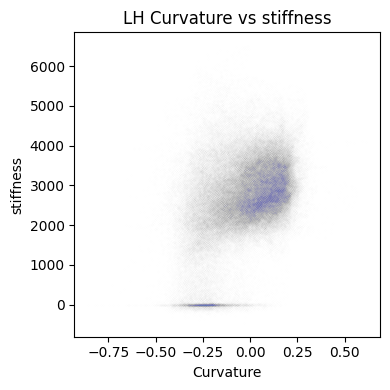

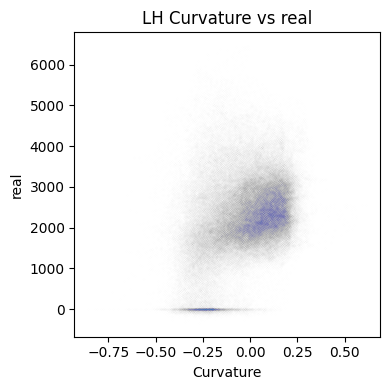

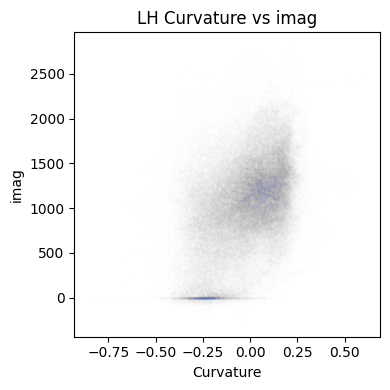

In [5]:
for prop in ["stiffness", "real", "imag"]:
    plt.figure(figsize=(4,4))
    plt.scatter(df["curvature"], df[prop], s=0.0001, alpha=0.3)
    plt.xlabel("Curvature")
    plt.ylabel(prop)
    plt.title(f"{hemi.upper()} Curvature vs {prop}")
    plt.tight_layout()
    plt.show()


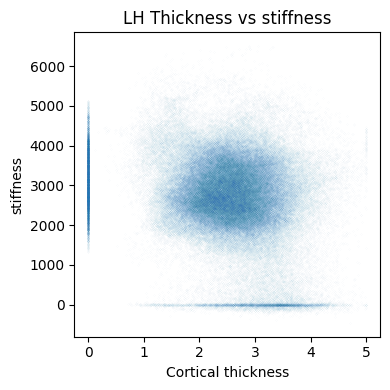

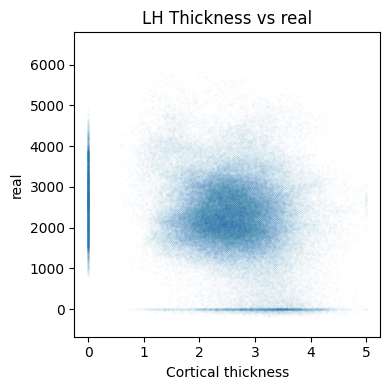

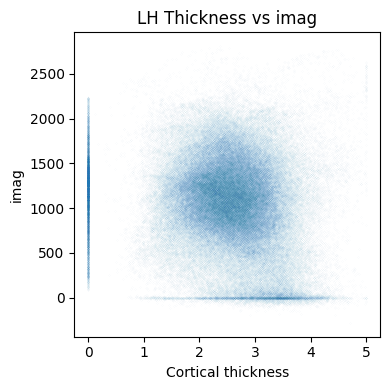

In [6]:
for prop in ["stiffness", "real", "imag"]:
    plt.figure(figsize=(4,4))
    plt.scatter(df["thickness"], df[prop], s=0.001, alpha=0.3)
    plt.xlabel("Cortical thickness")
    plt.ylabel(prop)
    plt.title(f"{hemi.upper()} Thickness vs {prop}")
    plt.tight_layout()
    plt.show()


In [7]:
df.corr(method="spearman")

,curvature,thickness,stiffness,real,imag
curvature,1.000000,-0.379909,0.347604,0.297456,0.397703
thickness,-0.379909,1.000000,-0.165889,-0.159946,-0.159595
stiffness,0.347604,-0.165889,1.000000,0.926928,0.534943
real,0.297456,-0.159946,0.926928,1.000000,0.256248
imag,0.397703,-0.159595,0.534943,0.256248,1.000000


In [8]:
df.corr(method="pearson")

,curvature,thickness,stiffness,real,imag
curvature,1.000000,-0.289677,0.381117,0.310846,0.415994
thickness,-0.289677,1.000000,-0.212603,-0.202224,-0.156096
stiffness,0.381117,-0.212603,1.000000,0.950643,0.586138
real,0.310846,-0.202224,0.950643,1.000000,0.324186
imag,0.415994,-0.156096,0.586138,0.324186,1.000000


### Correlation analysis

In [9]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

#mask = surface_brainmask[hemi]
def clean_pair(x, y):
    mask = (
        np.isfinite(x) &
        np.isfinite(y) 
    )
    #return x[mask], y[mask]
    return x, y

results = {}
# Correlations with curvature
for hemi in ["lh", "rh"]:
    results[hemi] = {}

    curv = curvature[hemi]

    for prop in ["stiffness", "real", "imag"]:
        mre = surface_mre[prop][hemi]

        x, y = clean_pair(curv, mre)

        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)

        results[hemi][prop] = {
            "N": len(x),
            "pearson_r": r_p,
            "pearson_p": p_p,
            "spearman_r": r_s,
            "spearman_p": p_s
        }

        print(
            f"{hemi.upper()} | {prop} | N={len(x)} | "
            f"Pearson r={r_p:.3f}, p={p_p:.2e} | "
            f"Spearman r={r_s:.3f}, p={p_s:.2e}"
        )


LH | stiffness | N=158340 | Pearson r=0.381, p=0.00e+00 | Spearman r=0.348, p=0.00e+00
LH | real | N=158340 | Pearson r=0.311, p=0.00e+00 | Spearman r=0.297, p=0.00e+00
LH | imag | N=158340 | Pearson r=0.416, p=0.00e+00 | Spearman r=0.398, p=0.00e+00
RH | stiffness | N=159948 | Pearson r=0.369, p=0.00e+00 | Spearman r=0.336, p=0.00e+00
RH | real | N=159948 | Pearson r=0.319, p=0.00e+00 | Spearman r=0.303, p=0.00e+00
RH | imag | N=159948 | Pearson r=0.350, p=0.00e+00 | Spearman r=0.332, p=0.00e+00


In [10]:
# Correlations with thickness
for hemi in ["lh", "rh"]:
    thick = thickness[hemi]

    for prop in ["stiffness", "real", "imag"]:
        mre = surface_mre[prop][hemi]

        x, y = clean_pair(thick, mre)

        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)

        results[hemi][prop + "_thickness"] = {
            "N": len(x),
            "pearson_r": r_p,
            "pearson_p": p_p,
            "spearman_r": r_s,
            "spearman_p": p_s
        }

        print(
            f"{hemi.upper()} | {prop} | N={len(x)} | "
            f"Pearson r={r_p:.3f}, p={p_p:.2e} | "
            f"Spearman r={r_s:.3f}, p={p_s:.2e} (thickness)"
        )


LH | stiffness | N=158340 | Pearson r=-0.213, p=0.00e+00 | Spearman r=-0.166, p=0.00e+00 (thickness)
LH | real | N=158340 | Pearson r=-0.202, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
LH | imag | N=158340 | Pearson r=-0.156, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
RH | stiffness | N=159948 | Pearson r=-0.190, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
RH | real | N=159948 | Pearson r=-0.202, p=0.00e+00 | Spearman r=-0.185, p=0.00e+00 (thickness)
RH | imag | N=159948 | Pearson r=-0.093, p=8.53e-307 | Spearman r=-0.084, p=4.20e-248 (thickness)
